# Overview
This notebook computes fluid dynamics quantities (given parameters of nitrogen gas and tubing) including:
- flow impedance using Darcy–Weisbach equation

$$Z = f \cdot \frac{L}{D} \cdot \frac{V^2}{2g}$$
$$\Delta P = \rho g Z = f \cdot \frac{L}{D} \cdot \frac{\rho V^2}{2}$$

- flow rate using Hagen-Poiseuille equation, expressed as:
$$\Delta P = \frac{8\mu LQ}{\pi R^4}$$
$$Q = \frac{\Delta P \pi R^4}{8\mu L}$$
- Reynolds number
- 

These quantities are defined and described in the Methods section.

## Imports

In [1]:
# Plotting
import matplotlib.pyplot as plt

# Vector math
import numpy as np

# PLotting settings
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

## Nitrogen gas constants 

In [2]:
# Dynamic viscosity of nitrogen at STP
MU = 1.7e-5     # Pa*s

# Universal gas constant
GAS_CONSTANT = 8.314        # J/(mol*K)

# Molar volume of an ideal gas at STP
MOLAR_VOLUME = 22.4         # L/mol

# Temperature, STP
TEMPERATURE_STP = 273.15    # K

# Density of nitrogen at STP
RHO_STP = 1.2506            # kg/m^3

# Specific gravity of nitrogen (relative to air)
SPECIFIC_GRAVITY = 0.967

# Ratio of specific heats for nitrogen
GAMMA = 1.4     

# Molar mass of nitrogen gas
MOLAR_MASS_N2 = 28.0134    # g/mol

# Gas constant for nitrogen (R = R_universal / M) in J/(kg*K)
R_N2 = GAS_CONSTANT / (MOLAR_MASS_N2 / 1000)  # Convert g/mol to kg/mol

## Unit conversions

In [3]:
# Inches to meters conversion factor
inch_to_meter = 0.0254

# Cubic meters per second to liters per minute conversion factor
m3s_to_lpm = 60000

# PSI to Pascals conversion factor
psi_to_pa = 6894.76

# SCFH to liters per minute conversion factor
scfh_to_lpm = 28.3168 / 60

## Methods

In [ ]:
# Cross sectional area
def calculate_cross_sectional_area(d):
    r = d / 2
    A = np.pi * r**2
    return A

# Hagen-Poiseuille equation
# Describes the pressure drop across a cylindrical tube of constant cross-sectional area for laminar flow.
def calculate_hagen_poiseuille(dp, r, l, mu):
    """
    Parameters:
        dp: Pressure drop across the tube (Pa)
        r: Radius of the tube (m)   
        l: Length of the tube (m)
        mu: Dynamic viscosity of the fluid (Pa*s)
    Returns:
        flow_rate: Volumetric flow rate (m^3/s)
        impedance: Hydraulic impedance (Pa*s/m^3)

    Governing relation for flow is flow Q * impedance Z = pressure drop dP
    Here, impedance Z = (8 * mu * l) / (pi * r^4) for laminar flow in a cylindrical tube.
    """
    impedance = (8 * mu * l) / (np.pi * r**4)   # Pa*s/m^3
    flow_rate = dp / impedance                  # m^3/s
    return flow_rate, impedance

# Reynolds number (unitless)
# This predicts whether the flow is laminar or turbulent. For laminar flow, Re < 2300. Turbulent flow occurs when Re > 4000. The range in between is transitional.
def calculate_reynolds_number(rho, v, d, mu):
    """
    Parameters:
        rho: Fluid density
        v: Flow velocity (speed)
        d: Characteristic length or dimension (e.g., pipe diameter)
        mu: Dynamic viscosity
        
        A typical quantity is also nu: Kinematic viscosity (nu = mu / rho)

    For convenience, returns: 
    (
        float: Reynolds number, 
        bool : flow type
    )

    Flow type:
        True if flow is laminar
        False if turbulent
        None if transitional
    """
    reynolds = (rho * v * d) / mu

    if reynolds < 2300:
        return reynolds, True
    elif reynolds > 4000:
        return reynolds, False
    else:
        return reynolds, None  # Transitional flow

# Blasius formula, giving the Darcy friction factor for turbulent flow in smooth pipes.
# Used to calculate the Darcy–Weisbach impedance
# Accurate for Reynolds number between 4000 and 100,000 (tubulent flow).
def calculate_friction_factor(reynolds):
    factor = 0.3164 * reynolds**(-0.25)
    return factor

# Darcy–Weisbach impedance: for incompressible fluid in a smooth cylindrical pipe.
def calculate_darcy_weisbach_impedance(
    friction_factor, 
    l, 
    d, 
    rho, 
    v, 
    Q
):
    """
    Parameters:
        friction_factor: Calculated using the Blasius equation for turbulent flow calculate_friction_factor()
        l: Length of the tube (m)
        d: Diameter of the tube (m)
        rho: Density of the fluid (kg/m^3)
        v: Flow velocity (m/s)
        Q: Volumetric flow rate (m^3/s)

    Note: expression is usually proportional to 1/g.
    But since Q = rho*g, we express as proportional to rho/Q so we can input a volumetric flow rate.
    Note also that a Pascal is N/m^2 = kg/(m*s^2)
    """
    impedance = friction_factor * (l / d) * (rho * v**2) / (2 * Q)    # Pa*s/m^3
    return impedance

# Calculates pressure increase rate for a given flow rate and volume, using ideal gas law.
def pressure_increase_rate(
    flow_slpm, 
    chamber_volume_m3, 
    temperature_K=TEMPERATURE_STP, 
    molar_volume_L_per_mol=MOLAR_VOLUME
):
    """
    Calculate pressure increase rate (dP/dt) in Pascals per minute in a fixed volume chamber.

    Parameters:
    - flow_slpm: flow rate at STP (litres per minute)
    - chamber_volume_m3: chamber volume in cubic meters
    - temperature_K: temperature in Kelvin (default 298 K)
    - molar_volume_L_per_mol: molar volume at STP in litres per mole (default 22.4 L/mol)

    Returns:
    - pressure increase rate in Pascals per minute

    Notes: From ideal gas law P = (n/V) * R * T, we can derive dP/dt = (R * T / V) * dn/dt, where dn/dt is the molar flow rate.
    """

    # flow rate to moles per minute
    dn_dt = flow_slpm / molar_volume_L_per_mol  # mol/min

    # dP/dt in Pascals per minute
    dP_dt = (GAS_CONSTANT * temperature_K / chamber_volume_m3) * dn_dt  # Pa/min

    return dP_dt

# Standard Sub-Critical Gas Flow Equation. Engineering formula used to size valves for gas flow.
def std_sub_critical_gas_flow(
    Cv, 
    P1_psi, 
    P2_psi, 
    T_C, 
    G=SPECIFIC_GRAVITY
):
    """
    Calculates nitrogen gas flow (std L/min) from Cv using the average pressure method.
    Assumes flow is sub-critical (not choked) and ideal gas behavior (gas not too compressed).

    Parameters:
    Cv       : Valve flow coefficient (unitless)
    P1_psi   : Inlet pressure (psia)
    P2_psi   : Outlet pressure (psia)
    T_C      : Temperature in Celsius
    G        : Specific gravity of gas (default for N2 = 0.967)

    Returns:
    Q_scfh : Flow rate in SCFH (standard cubic feet per hour)
    dP_dependence : The term dependent on pressure drop, useful for plotting flow vs pressure drop
    """
    # Convert temperature to Rankine (absolute scale for Fahrenheit)
    T_R = (T_C + 273.15) * 1.8

    # Calculate pressure drop and average pressure
    dP = P1_psi - P2_psi
    P_avg = (P1_psi + P2_psi) / 2

    if dP <= 0:
        return 0  # No flow if backpressure is too high

    # Return term dependent on dP for convenience in plotting flow vs pressure drop
    dP_dependence = 1360 * (dP / (G * T_R))**0.5 * P_avg**0.5

    # Flow in SCFH
    # Note: 1360 comes from Hours to seconds, Pounds to ounces, Gas constants, Standard atmospheric pressure constants.
    # Also, fluid velocity is proportional to the square root of the pressure drop over the average pressure.
    Q_scfh = Cv * dP_dependence

    return Q_scfh, dP_dependence

## Analysis

### Tubing impedances for laminar and turbulent flow

In [ ]:
# For laminar flow, calculate impedance and flow rate for tube at a given differential pressure (dP)

# Tube inner diameter and length
d = 0.435 * inch_to_meter
r = d/2
l = 18.55  # in meters

# Pressure drop (dP) across tube in Pascals
dp = 2 * psi_to_pa

flow, impedance = calculate_hagen_poiseuille(dp, r, l, MU)
flow_lpm = flow * m3s_to_lpm

print(f"Flow rate: {flow_lpm:.2f} L/min")
print(f"Impedance: {impedance:.2e} Pa*s/m^3")

Flow rate: 959.71 L/min
Impedance: 8.62e+05 Pa*s/m^3


velocity (in m/s) 166.82160012659742
Re: 135595.34
Turbulent flow? True


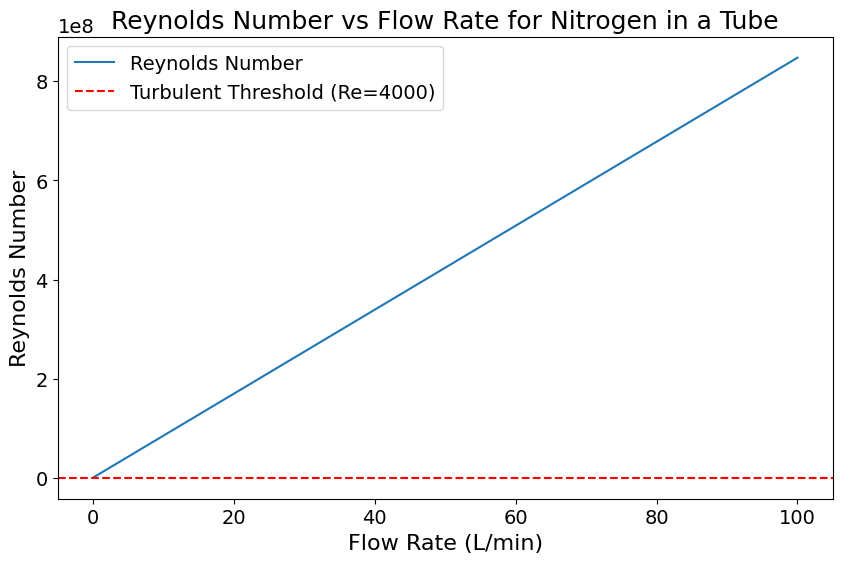

In [8]:
# Calculate Reynolds number
cross_area = calculate_cross_sectional_area(d)  
velocity = flow / cross_area
print("velocity (in m/s)", velocity)

Re, laminar = calculate_reynolds_number(RHO_STP, velocity, d, MU)
print(f"Re: {Re:.2f}")
print("Turbulent flow?", not laminar)

# Reynolds number over a range of flow rates
# Flow rates
flow_rates = np.linspace(0, 100, 100)
velocities = flow_rates / cross_area
Reynolds_numbers = [calculate_reynolds_number(RHO_STP, v, d, MU)[0] for v in velocities]
plt.figure(figsize=(10, 6))
plt.plot(flow_rates, Reynolds_numbers, label='Reynolds Number')
plt.axhline(4000, color='red', linestyle='--', label='Turbulent Threshold (Re=4000)')
plt.xlabel('Flow Rate (L/min)')
plt.ylabel('Reynolds Number')
plt.title('Reynolds Number vs Flow Rate for Nitrogen in a Tube')
plt.legend()
plt.show()

In [9]:
# Friction factor for turbulent flow
blasius = calculate_friction_factor(Re)
print("Blasius friction factor:", blasius)

# Calculate Darcy–Weisbach impedance (turbulent flow)
impedance = calculate_darcy_weisbach_impedance(blasius, l, d, RHO_STP, velocity, flow)
print(f"Impedance using Darcy–Weisbach (Pa*s/m^3): {impedance:.2e}")

# Expected flow rate for a given pressure drop using Darcy–Weisbach impedance
expected_flow = dp / impedance
expected_flow_lpm = expected_flow * m3s_to_lpm
print(f"Expected flow rate using Darcy–Weisbach impedance: {expected_flow_lpm:.2f} L/min")

Blasius friction factor: 0.016488277385360697
Impedance using Darcy–Weisbach (Pa*s/m^3): 3.01e+07
Expected flow rate using Darcy–Weisbach impedance: 27.47 L/min


### Pressure changes in a volume for varying input flow rate

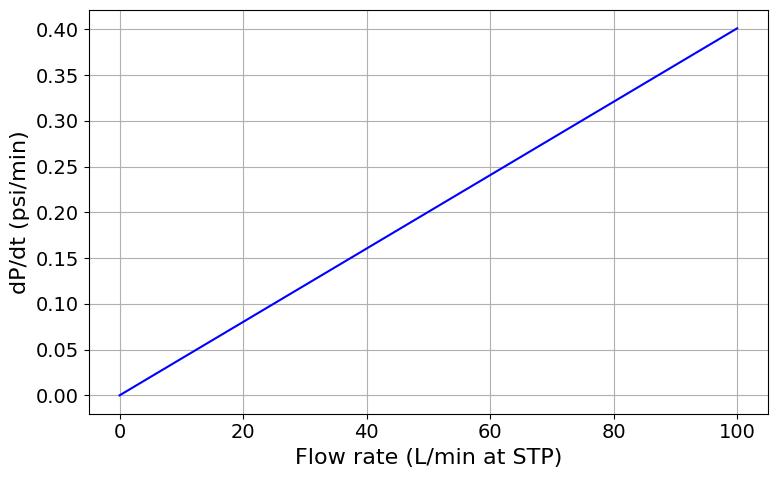

In [10]:
# Plotting pressure increase rate vs flow rate for a fixed volume chamber, using ideal gas law.
# Relates possible input flow rates from the purge system Flow Controller to the pressure increase rate in the radon barrier volume.
# Note: the flow rate of the flow controller will be changing in response to changing differential pressure. But this plot allows us to  see directly what the pressure increase rate would be for the maximum flow rate (once measured) and for the normal operation case where dP is steady (flow will be constant at some measured value).

# Parameters
volume = 4            # chamber volume in cubic meters
temperature = 298     # room temperature in Kelvin

# Flow rates
flow_rates = np.linspace(0, 100, 100)

# Calculate pressure increase rates for all flow rates
pressure_rates = [pressure_increase_rate(fr, volume, temperature_K=temperature) / psi_to_pa for fr in flow_rates]

# Plotting
plt.figure(figsize=(8,5))
plt.plot(flow_rates, pressure_rates, linestyle='-', color='b')
plt.xlabel("Flow rate (L/min at STP)", fontsize=16)
plt.ylabel("dP/dt (psi/min)", fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

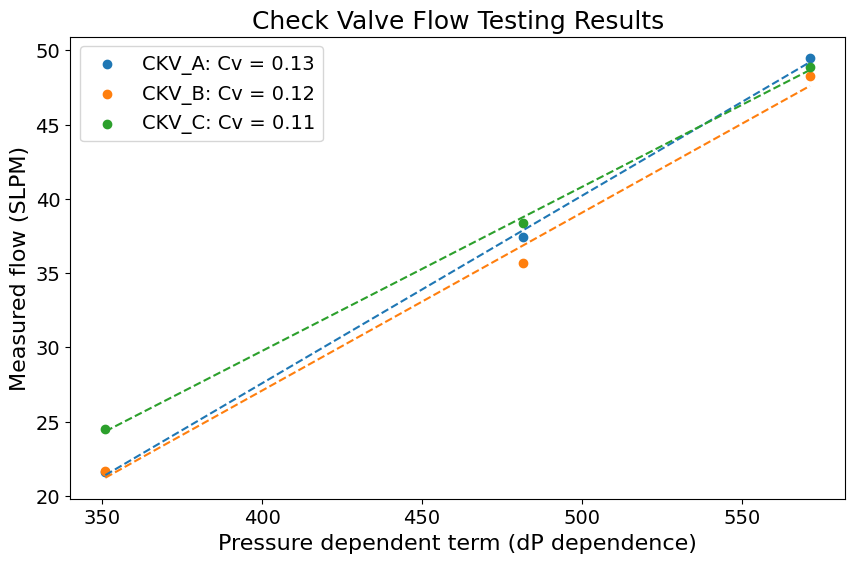

Computed flow (avg pressure method): 2588.681 std L/min


In [ ]:
# Calculate check valve flow coefficient based on results from check valve (CKV) flow testing.
# Results
set_dP = [2, 4, 6]
measured_flows = {      # SLPM
    "CKV_A": [21.6, 37.4, 49.5],
    "CKV_B": [21.7, 35.7, 48.3],
    "CKV_C": [24.5, 38.4, 48.9]
}

plt.figure(figsize=(10, 6))
for valve, flows in measured_flows.items():
    # Fit a line to the measured flows vs pressure terms caluclated by eqn for subcritical gas (using set dPs), to find the slope (Cv)
    dp_dependents = [std_sub_critical_gas_flow(Cv=1, P1_psi=18, P2_psi=18-dp, T_C=20)[1] for dp in set_dP]

    coeffs = np.polyfit(dp_dependents, flows, 1)  # Linear
    # print(f"coeffs: {coeffs}")
    Cv = coeffs[0]

    # Plot the measured flows vs the pressure dependent term, and the fitted line.
    plt.scatter(dp_dependents, flows, marker='o', label=f"{valve}: Cv = {Cv:.2f}")

    plt.plot(dp_dependents, np.poly1d(coeffs)(dp_dependents), linestyle='--')
plt.xlabel("Pressure dependent term (dP dependence)", fontsize=16)
plt.ylabel("Measured flow (SLPM)", fontsize=16)
plt.title("Check Valve Flow Testing Results", fontsize=18)
plt.legend()
plt.show()

# Compare measured to predicted using extracted Cv values for each valve.
# Calculate how much max flow you get out of the check valve with flow coefficient for a given differential pressure
# Example calculation: flow rate at cracking pressure = P2_psi - P1_psi = 0.1 psi. 
# For a pressure drop from testing flow rate with dewar set psig, P1 is atmospheric pressure (14.7 psi) and P2 is dewar pressure.
flow, dp_dependent_term = std_sub_critical_gas_flow(Cv=68, P1_psi=18, P2_psi=17.9, T_C=20)
flow_lpm = flow * scfh_to_lpm

print(f"Computed flow (avg pressure method): {flow_lpm:.3f} std L/min")

## Choked flow rate
Sub-critical flow occurs when the downstream absolute pressure P2 is greater than half of the upstream absolute pressure P1.

For a choked flow, velocity is constant regardless of increase in dP. Is the flow choked? If yes, what is the flow rate out?
$$\dot{m} = C_d A P_t \sqrt{\frac{\gamma}{R T_t}} \left( \frac{2}{\gamma + 1} \right)^{\frac{\gamma + 1}{2(\gamma - 1)}}$$

In [ ]:
# Methods
def choked_flowrate(Cd, A, P1, T0, gamma=GAMMA, R=R_N2):
    """
    Parameters:
        Cd       : Discharge coefficient (a correction factor for real-world friction and losses, typically 0.62 to 0.85)
        A        : Cross-sectional area of the throat or orifice (m^2)
        P1       : Stagnation (total) upstream pressure (Pa or psia)
        T0       : Stagnation (total) upstream temperature (K or °R)
        gamma    : Ratio of specific heats
        R        : Specific gas constant
    """
    mass_flow = Cd * A * P1 * np.sqrt(gamma / (R * T0)) * (2 / (gamma + 1))**((gamma + 1) / (2 * (gamma - 1)))
    return mass_flow

def subsonic_flowrate(Cd, A, P1, P2, T0, gamma=GAMMA, R=R_N2):
    term1 = (2 * gamma) / (gamma - 1)
    term2 = (P2 / P1)**(2 / gamma)
    term3 = (P2 / P1)**((gamma + 1) / gamma)
    mass_flow = Cd * A * P1 * np.sqrt((term1 / (R * T0)) * (1 - term2 + term3))
    return mass_flow

# Constants
Cd = 0.8                     # Discharge coefficient
gamma = 1.4                  # ratio of specific heats for Nitrogen
R = 296.8                    # J/kg.K for Nitrogen
T0 = 293.15                  # K (20°C)
P1_psi = 19                  # upstream pressure in psi (absolute)
P2_psi = 17                  # downstream pressure in psi (absolute)
P1 = P1_psi * 6894.76        # Convert to Pa
P2 = P2_psi * 6894.76
rho_stp = 1.2506             # kg/m³ at STP

# Orifice diameter (3/8 inch)
d_inch = 3/8
d_m = d_inch * 0.0254        # Convert to meters
A = np.pi * (d_m/2)**2       # Area in m²

# Choking pressure ratio
choke_ratio = (2 / (gamma + 1))**(gamma / (gamma - 1))

# Check for choked flow
if P2 / P1 <= choke_ratio:
    print("Flow is choked.")
    mass_flow = choked_flowrate(Cd, A, P1, T0, gamma, R)
else:
    print("Flow is subsonic.")
    mass_flow = subsonic_flowrate(Cd, A, P1, P2, T0, gamma, R)

# Convert to volumetric flow at STP
vol_flow_m3_s = mass_flow / rho_stp
vol_flow_lpm = vol_flow_m3_s * 1000 * 60  # convert m³/s to L/min

print(f"Volumetric flow rate (L/min): {vol_flow_lpm:.2f}")

## Check valve flow rate
Plot the maximum flow rate through a check valve for varying differential pressures across it.
Dependent variables include:
- parameters for nitrogen gas
- parameters of the tube in the path of the check valve (diameter and length)
- 

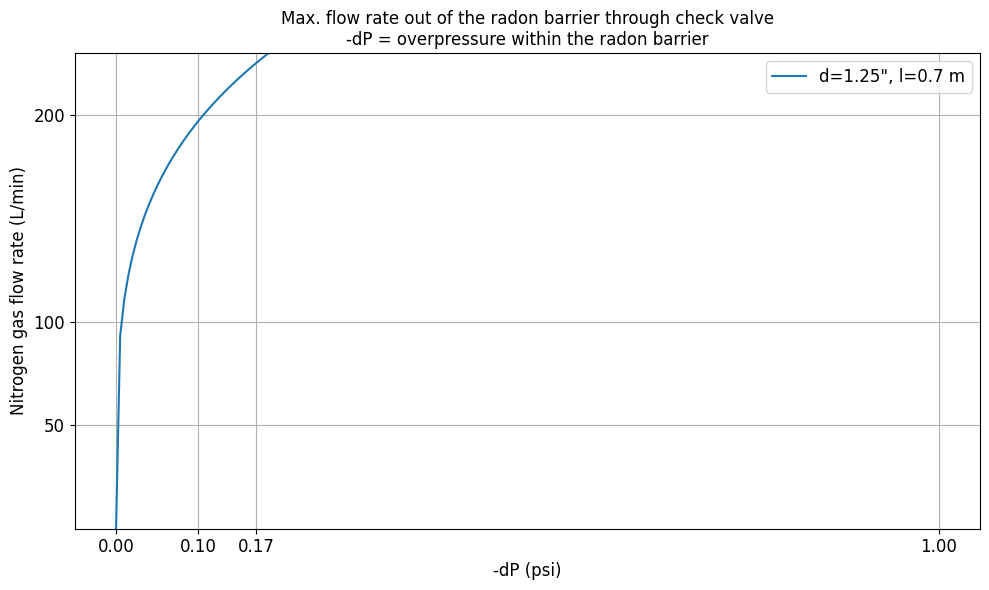

In [ ]:
# Nitrogen at STP
eta = 1.7e-5   # Pa·s
rho = 1.125     # kg/m³

# dP
dp_psi_array = np.linspace(0, 1, 200)
dp_array = dp_psi_array * 6894.6  # Convert to Pa

# Tube diameters in inches
diameters_inches = [0.5, 0.75, 1, 1.25, 1.5]
diameters_meters = [d * 0.0254 for d in diameters_inches]  # Convert to meters

# Tube lengths in meters
length_list = [0.7]  

plt.figure(figsize=(10, 6))

for l_fixed in length_list:
    for d_m in diameters_meters:
        r_fixed = d_m / 2
        A = np.pi * r_fixed**2

        Q_out_lpm = []
        Re_at_max_flow = None

        for dp_psi, dp in zip(dp_psi_array, dp_array):
            # Use Poiseuille-Hagen equation for Re < 4000 and Darcy-Weisbach for Re > 4000
            Z_poiseuille = (8 * eta * l_fixed) / (np.pi * r_fixed**4)
            Q_poiseuille = dp / Z_poiseuille
            v = Q_poiseuille / A
            Re = (rho * v * d_fixed) / eta

            if Re <= 4000:
                Q_used = Q_poiseuille
            else:
                f = 0.3164 * Re**(-0.25)
                Z_darcy = f * (l_fixed / d_fixed) * (rho * v**2) / (2 * Q_poiseuille)
                Q_used = dp / Z_darcy

            Q_lpm = Q_used * 60 * 1000  # Convert m³/s to L/min
            Q_out_lpm.append(Q_lpm)

            # Optional print for debugging
            #print(f'dP = {dp_psi:.2f} psi -> Flow rate = {Q_lpm:.2f} L/min')

            # Reynolds number for max ΔP
            if dp == dp_array[-1]:
                v_max = Q_used / A
                Re_at_max_flow = (rho * v_max * d_fixed) / eta

        label = f'd={d_inch} in, l={l_fixed} m'
        plt.plot(dp_psi_array, Q_out_lpm, label=label)

plt.xlabel("-dP (psi)", fontsize=12)
plt.ylabel("Nitrogen gas flow rate (L/min)", fontsize=12)
plt.title("Max. flow rate out of the radon barrier through check valve\n-dP = overpressure within the radon barrier", fontsize=12)
plt.xticks([0,0.1,0.17,1], fontsize=12)
plt.yticks([50,100,200,300,400])
plt.yticks(fontsize=12)
plt.ylim(0,230)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()